# Assignment 7 — Pareto Front Visualisation & Regional Pathways

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  

> **Pre-requisite:** Assignment 6 (MOEA Convergence & Reference Set). The `reference_set_utilitarian.csv` saved in Assignment 6 is required.

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Read and discuss **policy trade-offs** from a parallel-coordinates visualisation.
2. Interpret **regionalised emission control pathways** on a global map.
3. Connect Pareto front insights to actor perspectives and the XLRM framework.

---

## Background

### Trade-off analysis

A solution is **Pareto-optimal** if you cannot improve one objective without worsening another. The **parallel-coordinates plot** is the standard visualisation for exploring trade-offs across 4+ objectives simultaneously:

- Each vertical axis represents one objective.
- Each line represents one non-dominated policy.
- A **crossing** between two adjacent axes reveals a trade-off: solutions that score well on one objective tend to score poorly on the other.
- Axes are oriented so that **up = better** on every axis, making crossings immediately visible.

### Regional emission control rates

The JUSTICE model assigns an **emission control rate (ECR)** to each of the 57 RICE50 world regions. ECR ranges from 0 (no abatement) to 1 (full decarbonisation). The RBF policy computes the ECR for each region based on the current climate state (temperature and its rate of change).

Visualising the ECR at the end of the simulation horizon on a world map reveals **which regions are expected to decarbonise most aggressively** under each policy, and how this varies between policies optimised for different objectives.

---

## Overview

Starting from the reference set saved in Assignment 6, you will:

1. **Visualise the Pareto front** with a parallel-coordinates plot showing all four objectives.
2. **Map regional ECR pathways** by re-running JUSTICE with four anchor policies and plotting the end-of-horizon ECR per RICE50 region on a world map.

## Setup — Imports and configuration

The cell below imports all required packages, applies the Python 3.14 compatibility patch for `matplotlib.path.Path`, and loads the cross-seed reference set produced in Assignment 6.

In [2]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import os, sys, glob, re, json, copy
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Plotting / analysis helpers
import seaborn as sns
from IPython.display import display

try:
    from ema_workbench.analysis import parcoords
    PARCOORDS_AVAILABLE = True
except Exception as e:
    PARCOORDS_AVAILABLE = False
    print("parcoords not available:", e)

# Path setup
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")

# This notebook is inside the Yoran repo.
RESULTS_ROOT = os.path.join(_NOTEBOOK_DIR, "results")
_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

RUNS_TO_COMPARE = [
    "PRIORITARIAN_50000_9845531",
    "PRIORITARIAN_50000_1234567",
    "PRIORITARIAN_50000_2345678",
    "PRIORITARIAN_50000_3456789",
    "PRIORITARIAN_50000_4567890",

    "UTILITARIAN_50000_9845531",
    "UTILITARIAN_50000_1234567",
    "UTILITARIAN_50000_2345678",
    "UTILITARIAN_50000_3456789",
    "UTILITARIAN_50000_4567890",
]

print("Notebook dir :", _NOTEBOOK_DIR)
print("Results root :", RESULTS_ROOT)
print("Results exist:", os.path.exists(RESULTS_ROOT))
print("Plots dir    :", _PLOTS_DIR)
print("Assignment 7 setup OK")

Notebook dir : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased
Results root : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results
Results exist: True
Plots dir    : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots
Assignment 7 setup OK


In [3]:
# ── Load all 50k Pareto fronts ───────────────────────────────────────────────

all_fronts = []

for run_name in RUNS_TO_COMPARE:
    welfare_lens, nfe_str, seed_str = run_name.split("_")
    seed = int(seed_str)
    nfe = int(nfe_str)

    f = os.path.join(RESULTS_ROOT, run_name, f"pareto_front_{seed}.csv")

    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing Pareto file:\n{f}")

    df = pd.read_csv(f)

    df["welfare_lens"] = welfare_lens
    df["nfe"] = nfe
    df["seed"] = seed
    df["run_name"] = run_name

    all_fronts.append(df)

all_fronts = pd.concat(all_fronts, ignore_index=True)

print("Loaded Pareto-front data")
print(f"Total solutions: {len(all_fronts)}")

summary = (
    all_fronts
    .groupby(["welfare_lens", "seed"])
    .size()
    .rename("n_solutions")
    .reset_index()
)

display(summary)

print("\nObjective summary by welfare lens:")
display(
    all_fronts
    .groupby("welfare_lens")[OBJECTIVE_COLS]
    .describe()
    .round(3)
)

Loaded Pareto-front data
Total solutions: 1208


,welfare_lens,seed,n_solutions
0,PRIORITARIAN,1234567,247
1,PRIORITARIAN,2345678,221
2,PRIORITARIAN,3456789,208
3,PRIORITARIAN,4567890,240
4,PRIORITARIAN,9845531,244
5,UTILITARIAN,1234567,9
6,UTILITARIAN,2345678,9
7,UTILITARIAN,3456789,10
8,UTILITARIAN,4567890,10
9,UTILITARIAN,9845531,10



Objective summary by welfare lens:


welfare                                                      \
               count     mean    std      min      25%      50%      75%   
welfare_lens                                                               
PRIORITARIAN  1160.0  411.805  0.730  410.949  411.185  411.621  412.160   
UTILITARIAN     48.0  103.552  0.096  103.450  103.469  103.500  103.641   

                      fraction_above_threshold         ...  \
                  max                    count   mean  ...   
welfare_lens                                           ...   
PRIORITARIAN  413.750                   1160.0  0.594  ...   
UTILITARIAN   103.781                     48.0  0.652  ...   

             welfare_loss_damage            welfare_loss_abatement  \
                             75%        max                  count   
welfare_lens                                                         
PRIORITARIAN           35096.234  36491.036                 1160.0   
UTILITARIAN             3650.232   3655.279                   48.0   

                                                                       \
                    mean        std        min        25%         50%   
welfare_lens                                                            
PRIORITARIAN  100137.653  48704.668  13040.112  71034.823  111750.163   
UTILITARIAN    12875.754   4656.478  10789.924  10821.040   10988.450   

                                     
                     75%        max  
welfare_lens                         
PRIORITARIAN  139326.741  166609.96  
UTILITARIAN    11182.176   26006.79  

[2 rows x 32 columns]

## Data loaded for Assignment 7

This notebook visualises the final Pareto fronts from the full 50,000 NFE optimisation runs. We compare two welfare lenses: `PRIORITARIAN`, representing the Youth & Future Generations Coalition’s low-discount framing, and `UTILITARIAN`, representing the higher-discount comparison.

Both welfare lenses were run with the same NFE budget and the same five seeds, so the comparison is fair. The Prioritarian runs produce many more Pareto solutions than the Utilitarian runs, which already suggests that the low-discount welfare framing exposes a richer set of climate-policy trade-offs.

---

## Step 1 — Pareto Front Visualisation & Trade-off Discussion

The **parallel-coordinates plot** shows all four objectives across the reference set.  
Each line is one policy; axes are oriented so that **up = better** on every axis.  
Lines are coloured by `fraction_above_threshold` (climate risk) — darker red = higher risk.  
Crossings between adjacent axes reveal **trade-offs**: solutions that are better on one axis tend to be worse on another.

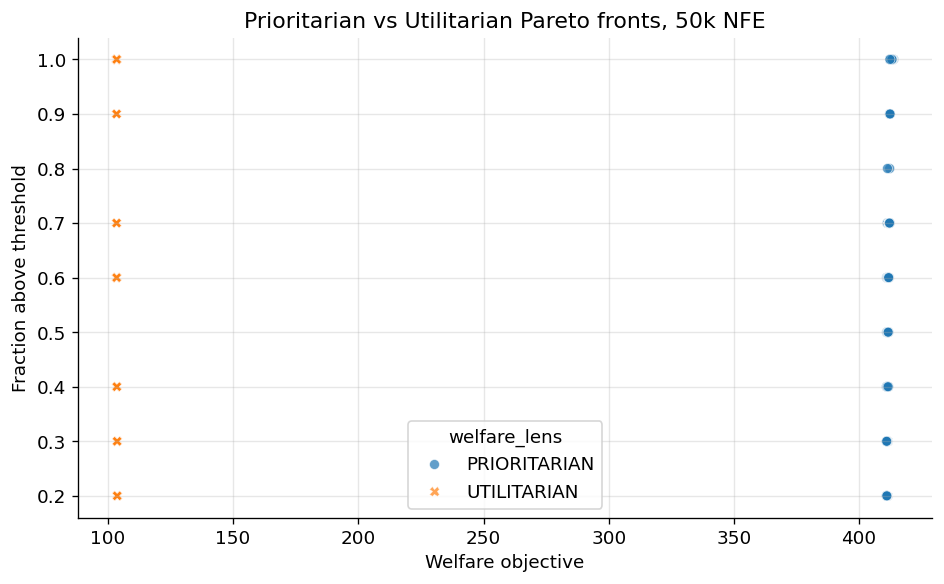

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_pareto_prioritarian_vs_utilitarian.png


In [5]:
# ── Basic Prioritarian vs Utilitarian Pareto comparison ──────────────────────

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=all_fronts,
    x="welfare",
    y="fraction_above_threshold",
    hue="welfare_lens",
    style="welfare_lens",
    alpha=0.7
)

plt.title("Prioritarian vs Utilitarian Pareto fronts, 50k NFE")
plt.xlabel("Welfare objective")
plt.ylabel("Fraction above threshold")
plt.grid(alpha=0.3)
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_pareto_prioritarian_vs_utilitarian.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

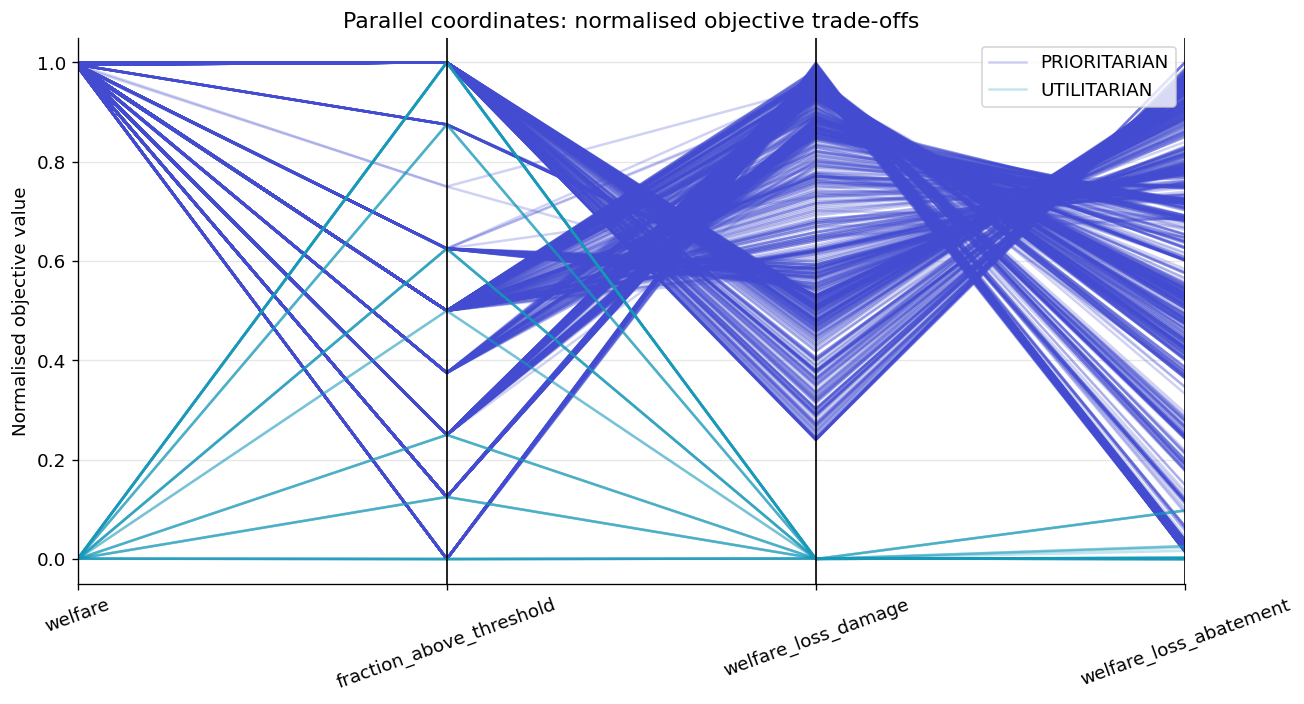

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_parallel_coordinates_objectives.png


In [7]:
# ── Parallel-coordinates plot for objective trade-offs ───────────────────────

plot_df = all_fronts[
    ["welfare_lens", "seed"] + OBJECTIVE_COLS
].copy()

norm_df = plot_df.copy()

for col in OBJECTIVE_COLS:
    lo = norm_df[col].min()
    hi = norm_df[col].max()
    if hi > lo:
        norm_df[col] = (norm_df[col] - lo) / (hi - lo)
    else:
        norm_df[col] = 0.0

plt.figure(figsize=(11, 6))

pd.plotting.parallel_coordinates(
    norm_df,
    class_column="welfare_lens",
    cols=OBJECTIVE_COLS,
    alpha=0.25
)

plt.title("Parallel coordinates: normalised objective trade-offs")
plt.ylabel("Normalised objective value")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_parallel_coordinates_objectives.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

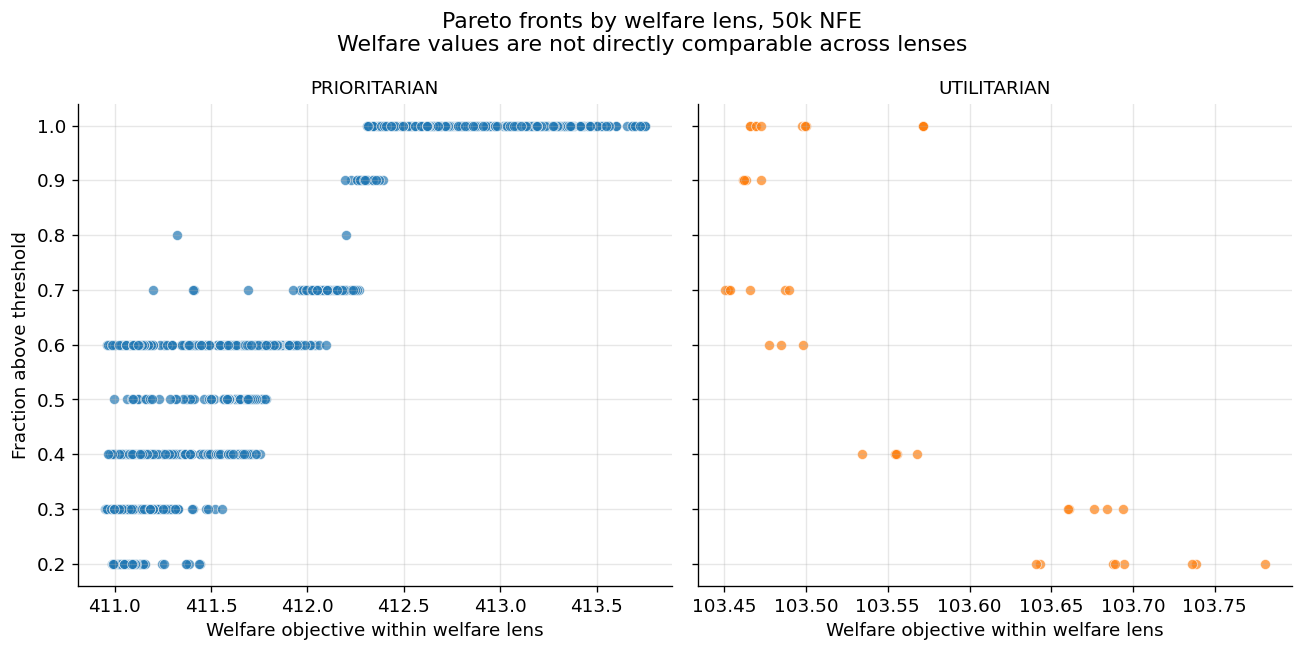

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_pareto_faceted_by_welfare_lens.png


In [8]:
# ── Better plot: separate welfare lenses ─────────────────────────────────────

g = sns.FacetGrid(
    all_fronts,
    col="welfare_lens",
    hue="welfare_lens",
    height=5,
    aspect=1.1,
    sharex=False,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="welfare",
    y="fraction_above_threshold",
    alpha=0.7
)

g.set_axis_labels("Welfare objective within welfare lens", "Fraction above threshold")
g.set_titles("{col_name}")
g.fig.suptitle(
    "Pareto fronts by welfare lens, 50k NFE\n"
    "Welfare values are not directly comparable across lenses",
    y=1.08
)

for ax in g.axes.flat:
    ax.grid(alpha=0.3)

out_path = os.path.join(_PLOTS_DIR, "a07_pareto_faceted_by_welfare_lens.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

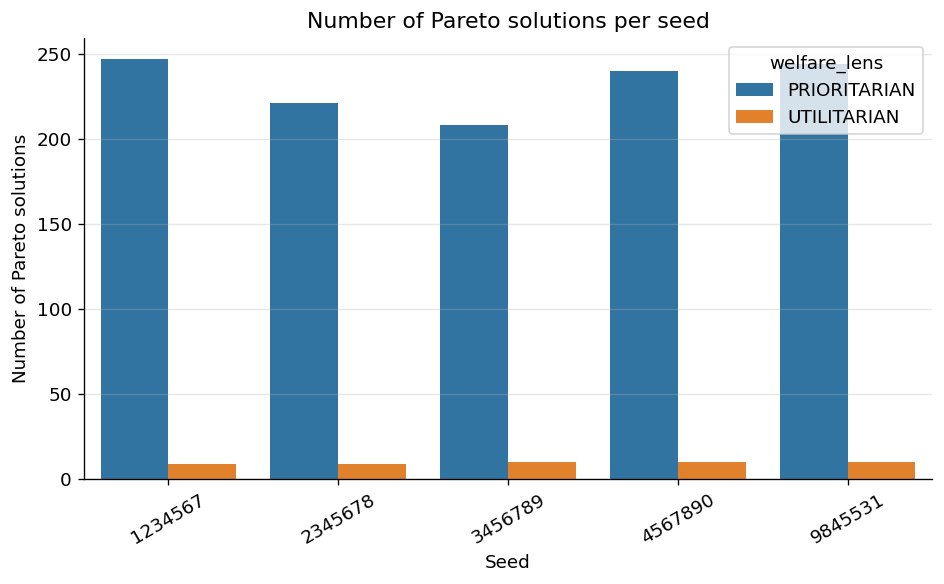

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_pareto_solution_counts.png


,welfare_lens,seed,n_solutions
0,PRIORITARIAN,1234567,247
1,PRIORITARIAN,2345678,221
2,PRIORITARIAN,3456789,208
3,PRIORITARIAN,4567890,240
4,PRIORITARIAN,9845531,244
5,UTILITARIAN,1234567,9
6,UTILITARIAN,2345678,9
7,UTILITARIAN,3456789,10
8,UTILITARIAN,4567890,10
9,UTILITARIAN,9845531,10


In [9]:
# ── Pareto solution counts per seed ──────────────────────────────────────────

solution_counts = (
    all_fronts
    .groupby(["welfare_lens", "seed"])
    .size()
    .rename("n_solutions")
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=solution_counts,
    x="seed",
    y="n_solutions",
    hue="welfare_lens"
)

plt.title("Number of Pareto solutions per seed")
plt.xlabel("Seed")
plt.ylabel("Number of Pareto solutions")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_pareto_solution_counts.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

display(solution_counts)

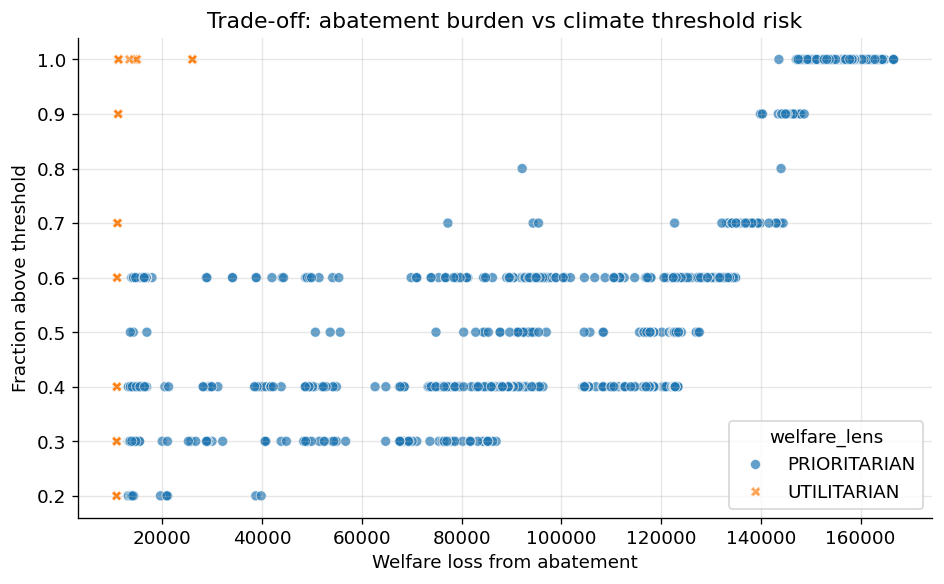

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_abatement_vs_threshold_risk.png


In [10]:
# ── Actor-relevant trade-off: climate risk vs abatement loss ─────────────────

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=all_fronts,
    x="welfare_loss_abatement",
    y="fraction_above_threshold",
    hue="welfare_lens",
    style="welfare_lens",
    alpha=0.7
)

plt.title("Trade-off: abatement burden vs climate threshold risk")
plt.xlabel("Welfare loss from abatement")
plt.ylabel("Fraction above threshold")
plt.grid(alpha=0.3)
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_abatement_vs_threshold_risk.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

## Interpretation of the Prioritarian vs Utilitarian scatter plot

This plot should be interpreted cautiously. The welfare objective is calculated under different welfare accounting assumptions in the Prioritarian and Utilitarian runs, so the absolute welfare values are not directly comparable across the two lenses. The separation on the x-axis therefore does not mean that one lens is objectively better than the other.

The useful message from this plot is that the welfare lens changes the objective space. The Prioritarian and Utilitarian runs do not produce the same kind of Pareto front. This supports our mandate argument that discounting and welfare aggregation are political choices, not neutral technical details.

For policy selection, this plot is not sufficient. We therefore use additional visualisations: separate Pareto plots by welfare lens, solution-count comparisons, parallel-coordinate plots, and actor-specific candidate selection based on low threshold exceedance.

In [11]:
# ── Objective directions and labels ──────────────────────────────────────────

MINIMIZE_COLS = [
    "welfare",
    "fraction_above_threshold",
]

MAXIMIZE_COLS = [
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

OBJECTIVE_LABELS = {
    "welfare": "Welfare objective",
    "fraction_above_threshold": "Fraction above threshold",
    "welfare_loss_damage": "Welfare loss from damage",
    "welfare_loss_abatement": "Welfare loss from abatement",
}

print("Objective metadata ready.")

Objective metadata ready.


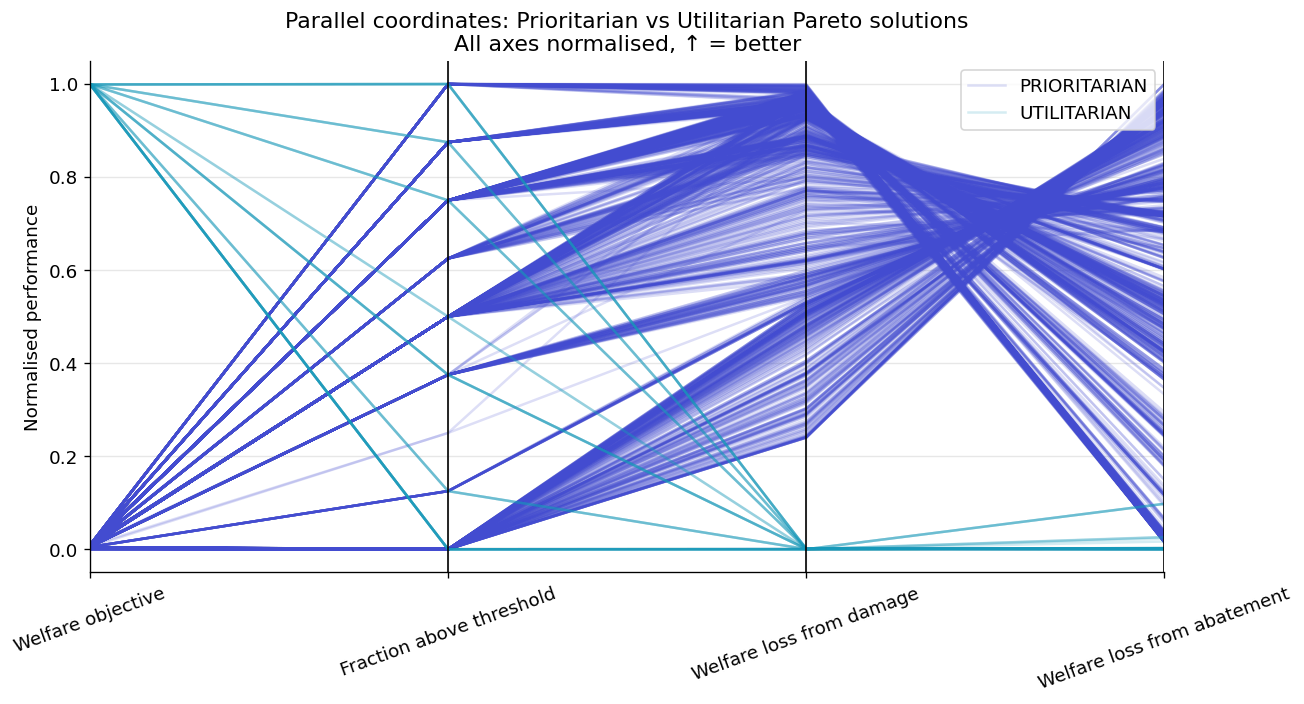

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_parallel_coordinates_all_fronts.png


In [12]:
# ── Actor-adapted parallel-coordinates plot ──────────────────────────────────
# Uses all loaded Pareto solutions from the 50k runs.
# Every axis is normalised so that higher = better.

plot_df = all_fronts[
    ["welfare_lens", "seed", "run_name"] + OBJECTIVE_COLS
].copy()

def normalise_actor_objectives(df):
    normed = df.copy()

    for col in OBJECTIVE_COLS:
        lo = normed[col].min()
        hi = normed[col].max()

        if hi <= lo:
            normed[col] = 0.5
            continue

        if col in MINIMIZE_COLS:
            # Lower raw value is better, so invert.
            normed[col] = 1.0 - (normed[col] - lo) / (hi - lo)
        else:
            # Higher raw value is better.
            normed[col] = (normed[col] - lo) / (hi - lo)

    return normed

norm_df = normalise_actor_objectives(plot_df)

plt.figure(figsize=(11, 6))

pd.plotting.parallel_coordinates(
    norm_df,
    class_column="welfare_lens",
    cols=OBJECTIVE_COLS,
    alpha=0.18,
)

plt.title(
    "Parallel coordinates: Prioritarian vs Utilitarian Pareto solutions\n"
    "All axes normalised, ↑ = better"
)
plt.ylabel("Normalised performance")
plt.xticks(
    ticks=range(len(OBJECTIVE_COLS)),
    labels=[OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS],
    rotation=20,
)
plt.grid(alpha=0.3)
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_parallel_coordinates_all_fronts.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

## Parallel-coordinates interpretation

This plot visualises all final Pareto solutions from the 50,000 NFE runs. Each line is one non-dominated policy solution. The objectives are normalised so that higher values mean better performance on that axis.

This visualisation is useful because it avoids collapsing all objectives into one score. That fits the course logic: model-based decision support should help decision-makers understand trade-offs rather than pretend that there is one objectively best policy. This is especially relevant for our actor, because discounting and welfare aggregation are political choices.

The Prioritarian solutions span a much wider set of trade-offs than the Utilitarian solutions. This reinforces the result from Assignment 6: the low-discount Prioritarian framing exposes a richer policy space, while the higher-discount Utilitarian framing produces a much smaller set of non-dominated alternatives.

For the Youth & Future Generations Coalition, the most important axis is `fraction_above_threshold`. Lower raw values are better because they indicate fewer unsafe climate futures. Since the plot is normalised with higher = better, better climate-safety policies appear higher on that axis.

In [14]:
# ── Actor-specific candidate policy selection ────────────────────────────────
# Actor 4: Youth & Future Generations Coalition
#
# Selection logic:
# 1. Use PRIORITARIAN only as the preferred low-discount welfare lens.
# 2. Prioritise low fraction_above_threshold.
# 3. Also avoid extreme welfare, damage, and abatement losses.
#
# Lower youth_score = better.

prior = all_fronts[all_fronts["welfare_lens"] == "PRIORITARIAN"].copy()

score_df = prior.copy()

score_components = [
    "fraction_above_threshold",
    "welfare",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

for col in score_components:
    lo = score_df[col].min()
    hi = score_df[col].max()

    if hi > lo:
        score_df[col + "_norm"] = (score_df[col] - lo) / (hi - lo)
    else:
        score_df[col + "_norm"] = 0.0

# Actor-specific weights.
# The largest weight goes to climate threshold exceedance.
score_df["youth_score"] = (
    0.50 * score_df["fraction_above_threshold_norm"]
    + 0.20 * score_df["welfare_norm"]
    + 0.20 * score_df["welfare_loss_damage_norm"]
    + 0.10 * score_df["welfare_loss_abatement_norm"]
)

candidate_policies = (
    score_df
    .sort_values("youth_score")
    .head(10)
    .copy()
)

cols_to_show = [
    "run_name",
    "seed",
    "youth_score",
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

display(candidate_policies[cols_to_show].round(4))

best_policy = candidate_policies.iloc[0]

print("Best actor-aligned candidate:")
for col in cols_to_show:
    val = best_policy[col]
    if isinstance(val, (int, float, np.integer, np.floating)):
        print(f"  {col:<35s}: {val:.4f}")
    else:
        print(f"  {col:<35s}: {val}")

,run_name,seed,youth_score,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
958,PRIORITARIAN_50000_4567890,4567890,0.1986,410.9866,0.2,35912.3227,13833.9366
1129,PRIORITARIAN_50000_4567890,4567890,0.2001,410.9908,0.2,36062.3092,13810.1829
471,PRIORITARIAN_50000_1234567,1234567,0.2001,410.9908,0.2,36072.2850,13771.8484
425,PRIORITARIAN_50000_1234567,1234567,0.2003,410.9877,0.2,36129.6880,13649.6098
441,PRIORITARIAN_50000_1234567,1234567,0.2003,410.9899,0.2,36116.0587,13654.3508
970,PRIORITARIAN_50000_4567890,4567890,0.2006,410.9920,0.2,36126.0058,13761.2815
1036,PRIORITARIAN_50000_4567890,4567890,0.2009,410.9947,0.2,36142.9644,13729.4968
1026,PRIORITARIAN_50000_4567890,4567890,0.2012,410.9932,0.2,36190.3162,13706.7208
735,PRIORITARIAN_50000_3456789,3456789,0.2014,411.0972,0.2,35325.1687,13183.0489
477,PRIORITARIAN_50000_1234567,1234567,0.2017,411.0112,0.2,36088.0950,13805.3046


Best actor-aligned candidate:
  run_name                           : PRIORITARIAN_50000_4567890
  seed                               : 4567890.0000
  youth_score                        : 0.1986
  welfare                            : 410.9866
  fraction_above_threshold           : 0.2000
  welfare_loss_damage                : 35912.3227
  welfare_loss_abatement             : 13833.9366


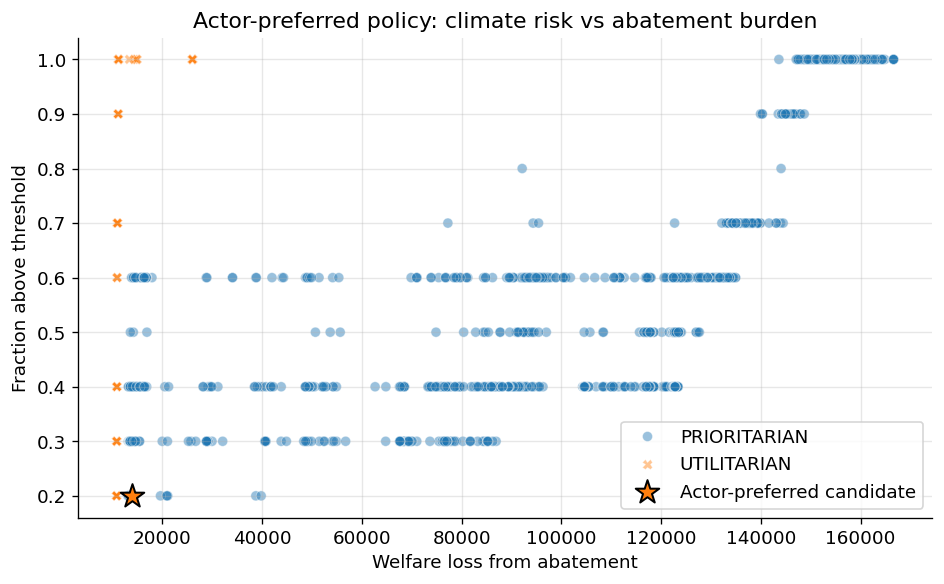

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_actor_preferred_policy.png


In [15]:
# ── Highlight actor-preferred candidate on climate-risk vs abatement plot ─────

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=all_fronts,
    x="welfare_loss_abatement",
    y="fraction_above_threshold",
    hue="welfare_lens",
    style="welfare_lens",
    alpha=0.45,
)

plt.scatter(
    best_policy["welfare_loss_abatement"],
    best_policy["fraction_above_threshold"],
    s=220,
    marker="*",
    edgecolor="black",
    linewidth=1.2,
    label="Actor-preferred candidate",
    zorder=5,
)

plt.title("Actor-preferred policy: climate risk vs abatement burden")
plt.xlabel("Welfare loss from abatement")
plt.ylabel("Fraction above threshold")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_actor_preferred_policy.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

## Actor-preferred candidate

The selected candidate policy comes from the Prioritarian run with seed `4567890`. It has a `fraction_above_threshold` of 0.20, meaning it is among the strongest available policies on the climate-threshold diagnostic. This is the most important criterion for the Youth & Future Generations Coalition.

The policy is not selected because it is “objectively best” for everyone. It is selected because it matches our mandate: future welfare should count strongly, threshold exceedance should be minimised, and present abatement costs should not be used to justify unsafe long-term outcomes.

The abatement-related welfare loss is not zero, but that is expected. Climate safety requires mitigation effort. For our actor, this cost is politically acceptable if it substantially reduces the risk imposed on young and future generations.

In [17]:
# ── Compare actor-preferred Prioritarian policy with best Utilitarian threshold policies ──

util = all_fronts[all_fronts["welfare_lens"] == "UTILITARIAN"].copy()

best_util_threshold = (
    util
    .sort_values(["fraction_above_threshold", "welfare_loss_abatement"])
    .head(10)
    .copy()
)

# For this comparison, do not include youth_score for Utilitarian rows.
comparison_cols = [
    "run_name",
    "seed",
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

comparison_table = pd.concat([
    best_policy[comparison_cols].to_frame().T.assign(
        selection="Actor-preferred Prioritarian",
        youth_score=best_policy["youth_score"]
    ),
    best_util_threshold[comparison_cols].assign(
        selection="Best Utilitarian threshold alternatives",
        youth_score=np.nan
    )
], ignore_index=True)

display(
    comparison_table[
        ["selection", "youth_score"] + comparison_cols
    ].round({
        "youth_score": 4,
        "welfare": 4,
        "fraction_above_threshold": 4,
        "welfare_loss_damage": 4,
        "welfare_loss_abatement": 4,
    })
)

,selection,youth_score,run_name,seed,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
0,Actor-preferred Prioritarian,0.1986,PRIORITARIAN_50000_4567890,4567890,410.986556,0.2,35912.322717,13833.936587
1,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_4567890,4567890,103.68903,0.2,3652.404105,10789.924195
2,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_9845531,9845531,103.687571,0.2,3652.082588,10796.119229
3,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_3456789,3456789,103.694803,0.2,3652.757715,10797.525966
4,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_9845531,9845531,103.780893,0.2,3655.27881,10801.213629
5,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_2345678,2345678,103.640747,0.2,3650.678966,10807.270419
6,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_3456789,3456789,103.73844,0.2,3653.487039,10808.968803
7,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_4567890,4567890,103.73598,0.2,3653.248486,10810.950168
8,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_1234567,1234567,103.643,0.2,3650.524686,10811.592099
9,Best Utilitarian threshold alternatives,NaN,UTILITARIAN_50000_9845531,9845531,103.676075,0.3,3651.46696,10815.627596


## Comparison with Utilitarian threshold alternatives

The comparison table shows that some Utilitarian solutions also reach `fraction_above_threshold = 0.20`. This means we should not claim that only the Prioritarian welfare lens can find low-threshold policies.

However, the interpretation is still politically important. The Utilitarian alternatives reach similar threshold performance under a higher-discount welfare framing, but the Utilitarian Pareto fronts are much smaller overall. The Prioritarian runs expose a much richer set of non-dominated options, which gives our actor more room to negotiate between climate safety, damages, welfare, and abatement costs.

For the Youth & Future Generations Coalition, the Prioritarian candidate remains preferred because it matches the mandate’s normative position: future welfare should count strongly and should not be discounted away. The Utilitarian alternatives can be used strategically in the debate: if other actors rely on high-discount Utilitarian accounting, we can show that even their own framing contains policies with low threshold exceedance. Therefore, they cannot use discounting as an excuse for weak climate ambition.

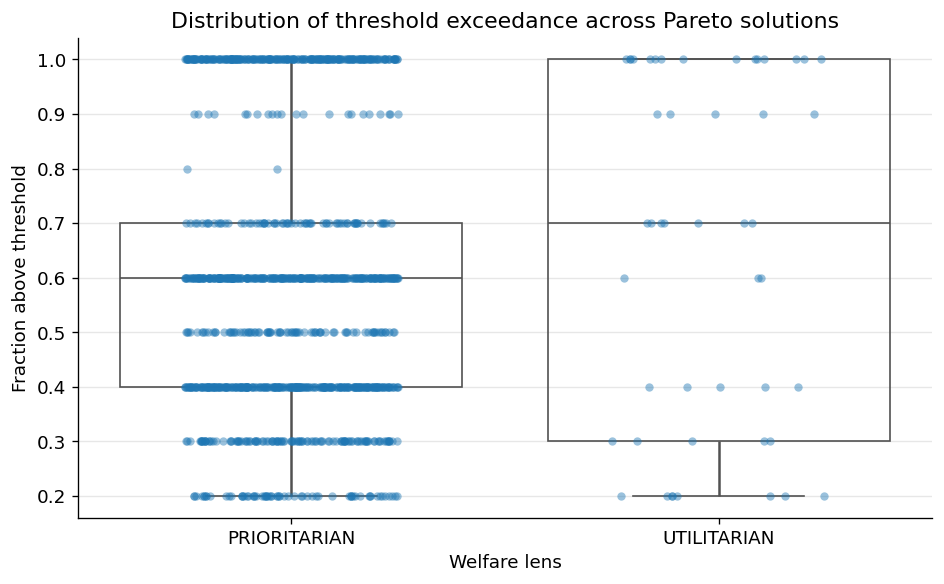

Saved → c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a07_threshold_distribution_by_lens.png


,count,mean,std,min,25%,50%,75%,max
welfare_lens,,,,,,,,
PRIORITARIAN,1160.0,0.594,0.256,0.2,0.4,0.6,0.7,1.0
UTILITARIAN,48.0,0.652,0.317,0.2,0.3,0.7,1.0,1.0


In [18]:
# ── Threshold performance distribution by welfare lens ───────────────────────

plt.figure(figsize=(8, 5))

sns.stripplot(
    data=all_fronts,
    x="welfare_lens",
    y="fraction_above_threshold",
    jitter=0.25,
    alpha=0.45
)

sns.boxplot(
    data=all_fronts,
    x="welfare_lens",
    y="fraction_above_threshold",
    showcaps=True,
    boxprops={"facecolor": "none"},
    showfliers=False,
    whiskerprops={"linewidth": 1.5}
)

plt.title("Distribution of threshold exceedance across Pareto solutions")
plt.xlabel("Welfare lens")
plt.ylabel("Fraction above threshold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out_path = os.path.join(_PLOTS_DIR, "a07_threshold_distribution_by_lens.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")

display(
    all_fronts
    .groupby("welfare_lens")["fraction_above_threshold"]
    .describe()
    .round(3)
)

## Threshold exceedance distribution

The threshold distribution shows that both welfare lenses contain some policies with low threshold exceedance. The key difference is not only the best available value, but the number and diversity of available policies. The Prioritarian runs contain many more Pareto solutions, while the Utilitarian runs contain only a small set of alternatives.

For our actor, this means that the low-discount framing is more useful for negotiation. It does not merely identify one acceptable policy; it gives a broader menu of policies that can be defended from an intergenerational justice perspective.

## Final conclusion for Assignment 7

The Pareto visualisations show that the welfare lens strongly affects the visible policy space. The Prioritarian and Utilitarian runs were produced with the same NFE budget and the same five seeds, so the comparison is fair. The Prioritarian runs generate many more non-dominated policies, while the Utilitarian runs produce a much thinner Pareto set.

The actor-preferred policy is selected from the Prioritarian front because this welfare lens best represents the Youth & Future Generations Coalition’s mandate. The selected candidate has `fraction_above_threshold = 0.20`, which is the best observed performance on the threshold diagnostic in the analysed Pareto set.

The Utilitarian comparison is also useful. Some Utilitarian policies reach similar threshold performance, which means other actors cannot argue that low threshold exceedance is only possible under our preferred welfare framing. However, the Utilitarian framing remains normatively problematic for our actor because it relies on higher discounting of future welfare.

The central conclusion is therefore not that one single policy is objectively best for everyone. The conclusion is that welfare accounting changes the visible trade-off space. Our coalition should demand that any agreement keeps near-zero social discounting explicit in compliance evaluation and should challenge actors who rely on high-discount welfare results without disclosing what this means for future generations.

Finally, the threshold diagnostic used here is 2°C-related, while our political red line remains 1.5°C. We therefore treat these results as a minimum stress test. If strong mitigation is needed even to perform well on the 2°C diagnostic, then a 1.5°C-compatible agreement requires at least as much ambition.

### Trade-off Discussion

**Reading the parallel-coordinates plot** (29 epsilon-nondominated solutions from the grand reference set; all axes oriented so **↑ = better**):

- **Welfare loss ↔ Climate risk (axes 1–2):** A crossing is visible between these adjacent axes. Solutions with *lower* total welfare loss (high on axis 1 — better overall wellbeing) tend to leave *more* RICE50 regions above 2 °C (lower on axis 2 — worse climate safety). Conversely, policies that achieve good climate safety (high on axis 2) incur more total welfare loss. **Reducing climate risk carries a welfare cost**: the additional mitigation spending needed to keep regions below 2 °C is absorbed into total welfare loss. The welfare loss range across the front is narrow — less than 0.3 % — so this trade-off is real but modest in magnitude.

- **Climate risk ↔ Welfare loss from damage (axes 2–3):** Lines between these two axes run in the *same* direction — **no crossing appears here**. Solutions that score high on climate safety (low fraction above 2 °C) also score high on the damage objective (more welfare preserved from climate impacts). Climate safety and damage avoidance are aligned in this reference set: deeper mitigation simultaneously reduces the fraction of regions above 2 °C and preserves more welfare from physical climate impacts.

- **Welfare loss from damage ↔ Welfare loss from abatement (axes 3–4):** The **largest and most consequential crossing** appears here. Solutions that score high on damage avoidance (axis 3) tend to score low on abatement cost avoidance (axis 4), and vice versa. This is the classical **mitigation trade-off**: preserving more welfare from climate damage requires spending more on emission reductions, which directly reduces the welfare saved from low abatement costs. The abatement axis shows the widest spread in the reference set — welfare loss from abatement ranges from roughly 10 800 to 26 000 across the 29 solutions (a ~140 % variation) — while damage avoidance varies by less than 1 %. 

- **Policy anchors:** The four coloured lines span the full objective range. The blue "Min climate risk" anchor achieves the lowest fraction above 2 °C but scores low on the welfare loss axis (higher total welfare cost). The orange "Max damage avoided" anchor pushes the damage objective to its upper bound but pays for it in lower abatement cost avoidance. The red "Min abatement cost" anchor retains the most welfare from low abatement spending but shows the worst climate outcome and lowest damage avoidance.


---

## Step 2 — Regional Emission Control Rate (ECR) Pathways

The RBF policy maps real-time climate state (temperature, warming rate) to an **emission control rate** for each of the 57 RICE50 regions.  
We re-run the JUSTICE model for the four best-performing policies on the Pareto front, each anchored to one objective:

| Label | Anchor | Direction |
|---|---|---|
| **W** | Maximum welfare | Highest welfare score |
| **R** | Minimum climate risk | Lowest fraction of scenarios above 2 °C |
| **D** | Minimum damage cost | Lowest welfare loss from climate damage |
| **Ab** | Minimum abatement cost | Lowest welfare loss from abatement |

We visualise the ECR snapshot at the **end of the simulation horizon (2300)** on world choropleth maps, one panel per anchor policy, showing the long-run decarbonisation intensity each policy prescribes to each RICE50 region.

> **Note:** We use 1 FAIR ensemble member here for speed. The policy RBF parameters come directly from the reference-set CSV.

In [ ]:
# ── JUSTICE imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import (
    Abatement, DamageFunction, Economy, WelfareFunction
)
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

# ── Model constants (from config/config_ssp245.json) ──────────────────────────
with open(os.path.join(_NOTEBOOK_DIR, "../config/config_ssp245.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year            = _cfg["start_year"],
    end_year              = _cfg["end_year"],
    data_timestep         = _cfg["data_timestep"],
    timestep              = _cfg["timestep"],
)
N_TIMESTEPS    = len(_time_horizon.model_time_horizon)
N_REGIONS      = len(DataLoader().REGION_LIST)
REGION_LIST    = list(DataLoader().REGION_LIST)   # 57 RICE50 region codes
N_INPUTS_RBF   = _cfg["n_inputs"]          # 2
N_RBFS         = _cfg["n_inputs"] + 2      # 4
SCENARIO       = _cfg["reference_ssp_rcp_scenario_index"]   # 2 = SSP2-RCP4.5
EC_START_TS    = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

# ── Helper: run JUSTICE for one policy row, return ECR array ─────────────────
def run_policy_ecr(policy_row, n_ensemble=1):
    """
    Run JUSTICE stepwise with the given RBF policy parameters.

    Parameters
    ----------
    policy_row : pd.Series  — one row from the reference set
    n_ensemble : int        — number of FAIR ensemble members to use

    Returns
    -------
    ecr_mean : np.ndarray shape (N_REGIONS, N_TIMESTEPS)
        Mean constrained ECR across ensemble members.
    datasets : dict  — final JUSTICE evaluate() output
    """
    # Build RBF from policy parameters
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center_{i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii_{i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights_{i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    # Emission ramp-up constraint
    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    # FAIR ensemble members (1-based index; use first n_ensemble from linspace)
    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = 0.0
    diff      = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)   # average over ensemble
    return ecr_mean, datasets


# ── Select four anchor policies from the reference set ───────────────────────
obj_ref = ref_set[OBJECTIVE_COLS]

# welfare is maximised (higher = better); the other three are minimised
idx_W  = obj_ref["welfare"].idxmax()
idx_R  = obj_ref["fraction_above_threshold"].idxmin()
idx_D  = obj_ref["welfare_loss_damage"].idxmin()
idx_Ab = obj_ref["welfare_loss_abatement"].idxmin()

anchors = {
    "W  — Max welfare":        idx_W,
    "R  — Min climate risk":   idx_R,
    "D  — Min damage cost":    idx_D,
    "Ab — Min abatement cost": idx_Ab,
}

print("Anchor policies selected from Pareto reference set:\n")
for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

print("Running JUSTICE model for all four anchor policies ...")
ecr_W,  _ = run_policy_ecr(ref_set.loc[idx_W],  n_ensemble=1)
ecr_R,  _ = run_policy_ecr(ref_set.loc[idx_R],  n_ensemble=1)
ecr_D,  _ = run_policy_ecr(ref_set.loc[idx_D],  n_ensemble=1)
ecr_Ab, _ = run_policy_ecr(ref_set.loc[idx_Ab], n_ensemble=1)
print("Done.")

In [5]:
# ── Map world countries to RICE50 regions via ISO-3166 codes ─────────────────
import importlib.util, pathlib, json as _json

_rice50_dict_path = os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(_rice50_dict_path) as _f:
    _rice50_dict = _json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France":     "fra",
    "Norway":     "nor",
    "Kosovo":     "oeu",
    "N. Cyprus":  "tur",
    "Somaliland": "rsaf",
}

# ── Extract end-of-horizon ECR snapshot ───────────────────────────────────────
t_end      = ecr_W.shape[1] - 1
snap_year  = int(_time_horizon.model_time_horizon[t_end])

print(f"End-of-horizon snapshot: timestep {t_end} = year {snap_year}")

def _snap_end(arr):
    return {REGION_LIST[i]: arr[i, t_end] for i in range(N_REGIONS)}

ecr_end = {
    "W":  _snap_end(ecr_W),
    "R":  _snap_end(ecr_R),
    "D":  _snap_end(ecr_D),
    "Ab": _snap_end(ecr_Ab),
}

# ── Load world shapefile and assign regions ───────────────────────────────────
_pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(_pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")
world = gpd.read_file(_ne_shp)

world["rice50"] = world["iso_a3"].map(iso_to_rice50)
mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = world.loc[mask_missing, "name"].map(_name_fallback)

for policy, region_ecr in ecr_end.items():
    world[f"ecr_{policy}"] = world["rice50"].map(region_ecr)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# ── Dissolve into 57 RICE50 region polygons ───────────────────────────────────
ecr_cols_map = [f"ecr_{p}" for p in ["W", "R", "D", "Ab"]]

regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols_map]

import geopandas as _gpd
if not isinstance(regions_gdf, _gpd.GeoDataFrame):
    regions_gdf = _gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")

End-of-horizon snapshot: timestep 285 = year 2300


Countries mapped to RICE50 regions: 177/177
Dissolved to 57 RICE50 regions


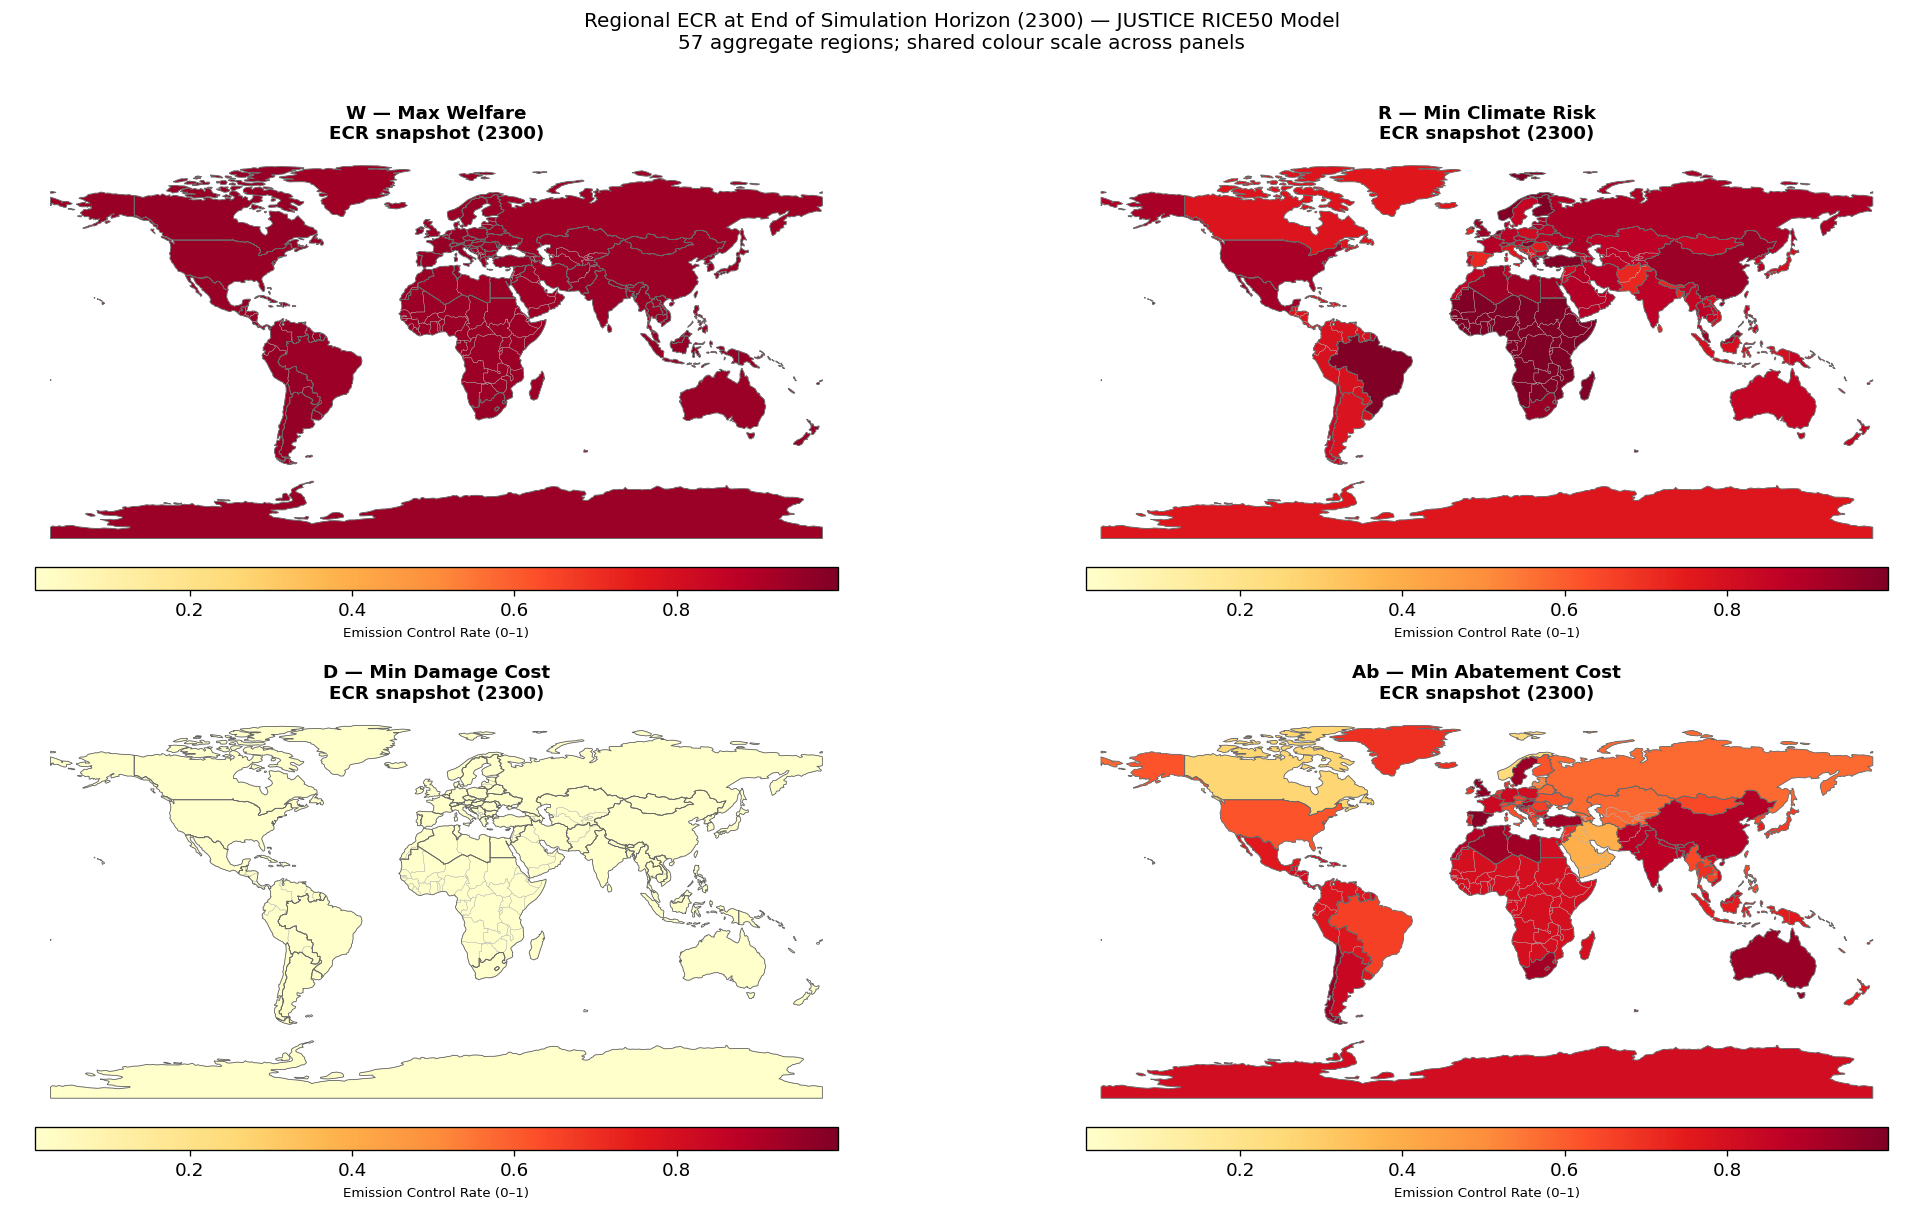

Figure saved: ecr_regional_map.png


In [6]:
# ── World map — end-of-horizon ECR snapshot (2×2 grid, one panel per policy) ──
panel_specs = [
    ("ecr_W",  f"W — Max Welfare\nECR snapshot ({snap_year})"),
    ("ecr_R",  f"R — Min Climate Risk\nECR snapshot ({snap_year})"),
    ("ecr_D",  f"D — Min Damage Cost\nECR snapshot ({snap_year})"),
    ("ecr_Ab", f"Ab — Min Abatement Cost\nECR snapshot ({snap_year})"),
]

all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])
vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]
    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                        pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) — JUSTICE RICE50 Model\n"
    "57 aggregate regions; shared colour scale across panels",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "ecr_regional_map.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: ecr_regional_map.png")

---

## Reflection Questions

**1. Trade-offs on the parallel-coordinates plot.** Identify the two axes that show the clearest crossing pattern (i.e., the strongest trade-off). Explain in 2–3 sentences why this trade-off exists in physical/economic terms.

> Two crossings are visible in the 29-solution reference set. The strongest is between **welfare loss** (axis 1) and **fraction above 2 °C** (axis 2, display correlation −0.76): policies that keep more regions below 2 °C incur more total welfare loss, because aggressive mitigation spending is directly absorbed into total welfare loss. A second crossing appears between **welfare loss from damage** (axis 3) and **welfare loss from abatement** (axis 4, correlation −0.57): avoiding more climate damage requires deploying more mitigation, which reduces the welfare saved from low abatement costs. Axes 2–3 show no crossing — better climate safety and lower damage improve together.

---

**2. Emission control rate map.** Compare the min-climate-risk policy and the min-abatement-cost policy on the world map. Which regions show the largest difference in ECR between the two? What does this imply about which regions are most influential in driving down climate risk?

> The largest ECR differences appear in major emitting regions — large economies in East and South Asia and North America — where the min-climate-risk policy (R) imposes substantially higher control rates than the min-abatement-cost policy (Ab). Smaller emitters in sub-Saharan Africa and South America show little difference. This implies that global climate risk is dominated by a small number of high-emission regions: the RBF policy under R concentrates emission reductions there because that is where temperature reductions per unit of abatement are greatest.

---

**3. Actor perspective.** Based on the parallel-coordinates plot and the regional ECR map, which policy from the reference set would you recommend to your actor? Justify your choice with explicit reference to at least two objectives and one regional consideration.

> Answers depend on the actor. A climate-vulnerable nation would favour policy R (min climate risk): it achieves the lowest fraction above 2 °C and the highest damage avoidance, at the cost of more total welfare loss — a cost borne mainly by high-emitting regions through elevated ECR requirements, which aligns with an equity argument. An industrialised economy prioritising near-term competitiveness might prefer policy Ab (min abatement cost): it preserves more welfare from low abatement spending, though the parallel-coordinates plot shows this comes with the worst climate outcome and lowest damage avoidance across the reference set.
